# Demonstration of output analysis/visualisation

In this demonstration we will run a refinement and then focus on interrogating the results. First we need to run the refinement.

In [44]:
# Imports used for this tutorial
import numpy as np
import os
from MDMC.control import Control
from MDMC.MD import Atom, Dispersion, LennardJones, Simulation, Universe

# Build universe with density 0.0176 atoms per AA^-3
density = 0.0176
universe = Universe(dimensions=23.0668)
Ar = Atom('Ar', charge=0., mass=36.0)
# Calculating number of Ar atoms needed to obtain density
n_ar_atoms = int(density * np.product(universe.dimensions))
universe.fill(Ar, num_struc_units=(n_ar_atoms))

Ar_dispersion = Dispersion(universe,
                           (Ar.atom_type, Ar.atom_type),
                           cutoff=8.,
                           function=LennardJones(epsilon=1.0243, sigma=3.36))

simulation = Simulation(universe,
                        engine="lammps",
                        time_step=10.18893,
                        temperature=120.,
                        traj_step=15)
simulation.minimize(n_steps=5000)
simulation.run(n_steps=10000, equilibration=True)

exp_datasets = [{'file_name':'../../doc/tutorials/data/Well_s_q_omega_Ar_data.xml',
                 'type':'SQw',
                 'reader':'xml_SQw',
                 'weight':1.,
                 'auto_scale':True,
                 'resolution':000}]

fit_parameters = universe.parameters
fit_parameters['sigma'].constraints = [2.8,3.8]
fit_parameters['epsilon'].constraints = [0.6, 1.4]

control = Control(simulation=simulation,
                  exp_datasets=exp_datasets,
                  fit_parameters=fit_parameters,
                  minimizer_type="GPO",
                  reset_config=True,
                  MD_steps=2000, 
                  equilibration_steps=2000)
control.refine(n_steps=25)

Universe created with:
  Dimensions       [23.07, 23.07, 23.07]
  Force field                       None
  Number of atoms                      0

LAMMPS (29 Sep 2021 - Update 3)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
LAMMPS (29 Sep 2021 - Update 3)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
LAMMPS output is captured by PyLammps wrapper
Total wall time: 0:00:00
Simulation created with lammps engine and settings:
  temperature  120.0

Control created with:
- Attributes                              -
  Minimizer                             GPO
  FoM type               ChiSquaredExpError
  Number of observables                   1
  Number of parameters                    2

Step         FoM Change state  Pred coords     Pred FoM epsilon (#5)   sigma (#6)
   0       327.1     Accepted

Look at the liklihood of the parameter values across the range of possible parameter values using a built-in helper method

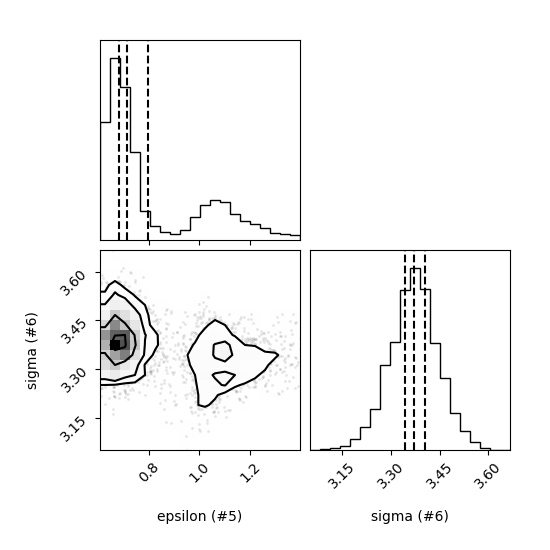

In [45]:
control.plot_results();

The `S(Q,w)` data is contained in the `Control` object used for the refinement. The `ObservablePair` contains both the experimentally measured `S(Q,w)` as well as the one calculated from the last MD simulation's `Trajectory`. 

In [46]:
# Extract the `ObservablePair` with the S(Q,w) data
obs_pair = control.observable_pairs[0]
# Extract the calculated S(Q,w) and apply the `rescale_factor` that minimises the 
# figure-of-merit (needed as the experimental data is in arbitrary units).
SQw_sim = obs_pair.MD_obs.SQw / obs_pair.rescale_factor
# Extract the measured S(Q,w) and its errors
SQw_exp = obs_pair.exp_obs.SQw
SQw_err = obs_pair.exp_obs.SQw_err
# Extract the Q and energy (E) values at which S(Q,w) was measured
Q = obs_pair.exp_obs.Q
E = obs_pair.exp_obs.E


Below is plotting code to look at S(Q,w) as a function of Q from both the experimental data and the final trajectory. Note that depending on the optimisation procedure used the final trajectory might not correspond to the most optimal point in the refinable parameter space.

In [47]:
# depending on exactly how/where this notebook is run the following widgets command for creating interactive plots might need changing
%matplotlib widget
from MDMC.trajectory_analysis.observables.obs_factory import ObservableFactory
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [ ]:
fig, ax = plt.subplots()
exp_line, = ax.plot(E, SQw_exp[0,0], linewidth=1, color='black')
sim_line, = ax.plot(E, SQw_sim[0,1,:], linewidth=1, color='blue')
ax.legend(labels=['experimental', 'refined'])
ax.set_xlabel('E (meV)')
ax.set_ylabel('S(Q,E) (arb)')
ax.set_title('Argon data')

fig.subplots_adjust(left=0.25, bottom=0.3)
Q_slider_ax  = fig.add_axes([0.25, 0.15, 0.65, 0.03], facecolor='lightgoldenrodyellow')
Q_slider = Slider(Q_slider_ax, 'Q index', 0, len(Q)-1, valinit=1, valstep=1)
Q_label=plt.text(1,1.7,f'Q={Q[1]} $\AA^{-1}$')


def Q_on_changed(val):
    exp_line.set_ydata(SQw_exp[0,val])
    sim_line.set_ydata(SQw_sim[0,val])
    Q_label.set_text(f'Q={Q[val]} $\AA^{-1}$')
    fig.canvas.draw_idle()
    ax.set_ylim(0,max(np.max(SQw_exp[0,val])+0.1,1e-5))

Q_slider.on_changed(Q_on_changed)
plt.show()

This is an example of how one could plot the PairDistributionFunction (`PDF`) if that was used as the type of `Observable` to refine. We can calculate the `PDF` from the last `Trajectory` of the refinement above (might not correspond to the most optimal place in parameter space) or we can also import a previously calculated/measured `PDF`.

In [49]:
PDF_sim=ObservableFactory.create_observable('PDF')
# extract the most recent trajectory from the refinement
traj=control.simulation.trajectory
# set the Universe of the trajectory for the correct dimensions of the MD box
traj.universe=control.simulation.universe
# set the distance points at which to calculate the PDF and then calculate PDF
PDF_sim.r=np.linspace(0, 20, 100)
PDF_sim.calculate_from_MD(traj)

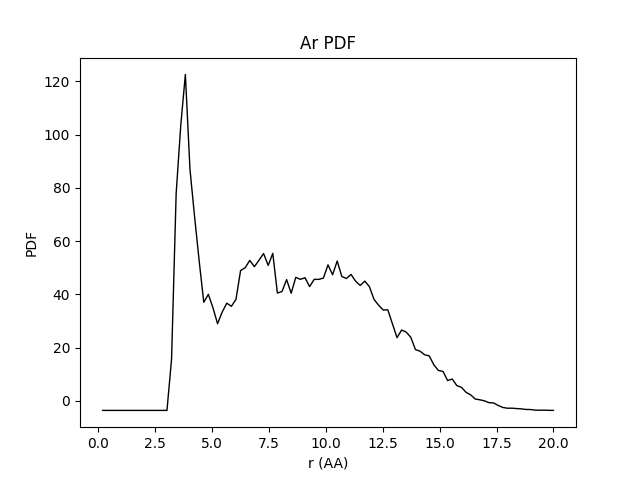

In [50]:
fig, ax = plt.subplots()
exp_line, = ax.plot(PDF_sim.r, PDF_sim.PDF, linewidth=1, color='black')
ax.set_xlabel('r (AA)')
ax.set_ylabel('PDF')
ax.set_title('Ar PDF')
plt.show()

Below is another example of plotting a `PDF` and partial pairs but this time the data is imported from a previous calculation (using NMOLDYN on a water trajetory to be precise) 

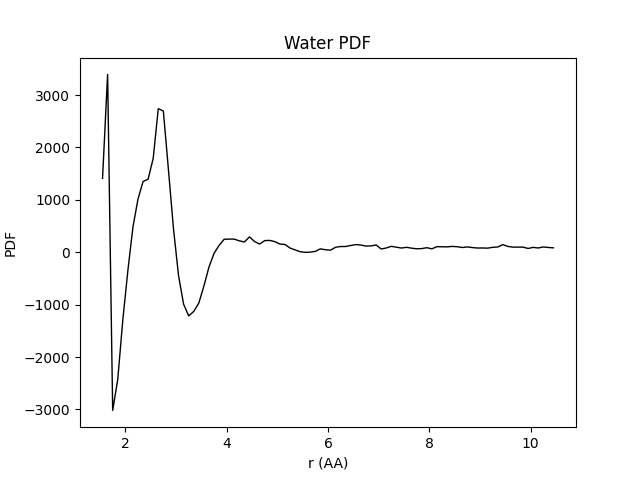

In [51]:
#import the data
obs=ObservableFactory.create_observable('PDF')
obs.read_from_file(reader='netCDFPDF', file_name='../../tests/test_data/calculated_observables/nMOLDYN_PDF_water.nc')
# then plot it
fig, ax = plt.subplots()
exp_line, = ax.plot(obs.r[15:], obs.PDF[15:], linewidth=1, color='black')
ax.set_xlabel('r (AA)')
ax.set_ylabel('PDF')
ax.set_title('Water PDF')
plt.show()